In [1]:
# ==========================================
# STUDENT PERFORMANCE PREDICTION SYSTEM
# Final Model Implementation
# ==========================================

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv(
    "../dataset/Students Performance Dataset.csv"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (5000, 23)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


In [4]:
print(df.info())

print("\nMissing Values:\n")

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   str    
 1   First_Name                  5000 non-null   str    
 2   Last_Name                   5000 non-null   str    
 3   Email                       5000 non-null   str    
 4   Gender                      5000 non-null   str    
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   str    
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 non-null   

In [5]:
# Create copy

clean_df = df.copy()

# Fill missing values

clean_df['Parent_Education_Level'] = (
    clean_df['Parent_Education_Level']
    .fillna(
        clean_df['Parent_Education_Level']
        .mode()[0]
    )
)

# Remove unnecessary columns

clean_df.drop(
    columns=[
        'Student_ID',
        'First_Name',
        'Last_Name',
        'Email'
    ],
    inplace=True
)

print("Shape After Cleaning:")

print(clean_df.shape)

Shape After Cleaning:
(5000, 19)


In [6]:
encoded_df = clean_df.copy()

encoders = {}

categorical_columns = encoded_df.select_dtypes(
    include=['object','string']
).columns

for col in categorical_columns:

    le = LabelEncoder()

    encoded_df[col] = le.fit_transform(
        encoded_df[col].astype(str)
    )

    encoders[col] = le

print("Encoding Completed")

encoded_df.head()

Encoding Completed


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,3,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,4,10.3,1,0,2,2,1,5.9
1,1,18,0,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,1,27.1,0,0,1,1,4,4.3
2,1,24,2,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,3,12.4,1,0,1,1,9,6.1
3,0,24,2,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,4,25.5,0,1,1,1,8,4.9
4,0,23,1,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,2,13.3,1,0,2,2,6,4.5


In [7]:
X = encoded_df.drop(
    ['Grade', 'Total_Score'],
    axis=1
)

y = encoded_df['Grade']

print(X.columns)

Index(['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score',
       'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities',
       'Internet_Access_at_Home', 'Parent_Education_Level',
       'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night'],
      dtype='str')


In [8]:
smote = SMOTE(
    random_state=42
)

X_smote, y_smote = smote.fit_resample(
    X,
    y
)

print(
    pd.Series(y_smote)
    .value_counts()
)

Grade
4    2307
1    2307
3    2307
2    2307
0    2307
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X_smote,
        y_smote,
        test_size=0.2,
        random_state=42
    )
)

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=20,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "Model Training Completed"
)

Model Training Completed


In [11]:
predictions = rf_model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)
print(
    "Random forest MOdel\n"
)

print(
    "Accuracy:",
    accuracy
)

print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test,
        predictions
    )
)

Random forest MOdel

Accuracy: 0.953185955786736

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       434
           1       0.96      0.99      0.97       461
           2       0.92      0.88      0.90       456
           3       0.92      0.91      0.91       477
           4       0.97      0.99      0.98       479

    accuracy                           0.95      2307
   macro avg       0.95      0.95      0.95      2307
weighted avg       0.95      0.95      0.95      2307



In [12]:
scores = cross_val_score(
    rf_model,
    X_smote,
    y_smote,
    cv=5,
    scoring='accuracy'
)

print(scores)

print(
    "\nAverage Accuracy:",
    scores.mean()
)

[0.94711747 0.95491981 0.95448635 0.9609883  0.96575639]

Average Accuracy: 0.9566536627654963


In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
5,Final_Score,0.238943
9,Projects_Score,0.214584
4,Midterm_Score,0.129374
6,Assignments_Avg,0.097821
8,Participation_Score,0.070506
7,Quizzes_Avg,0.066749
10,Study_Hours_per_Week,0.029962
3,Attendance (%),0.029296
16,Sleep_Hours_per_Night,0.027034
1,Age,0.018641


In [15]:
joblib.dump(
    rf_model,
    "../models/student_performance_model.pkl",
    compress=9
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [ ]:
joblib.dump(
    encoders,
    "../models/label_encoders.pkl"
)

print(
    "Encoders Saved Successfully"
)

Encoders Saved Successfully


In [ ]:
# ==========================================
# DROPOUT RISK ANALYSIS
# ==========================================

risk_df = clean_df.copy()

def risk_level(row):

    if row['Attendance (%)'] < 60:
        return "High Risk"

    elif row['Study_Hours_per_Week'] < 10:
        return "Medium Risk"

    elif row['Stress_Level (1-10)'] > 8:
        return "Medium Risk"

    else:
        return "Low Risk"

risk_df['Dropout_Risk'] = risk_df.apply(
    risk_level,
    axis=1
)

print(
    risk_df['Dropout_Risk']
    .value_counts()
)

Dropout_Risk
Low Risk       2584
Medium Risk    1443
High Risk       973
Name: count, dtype: int64


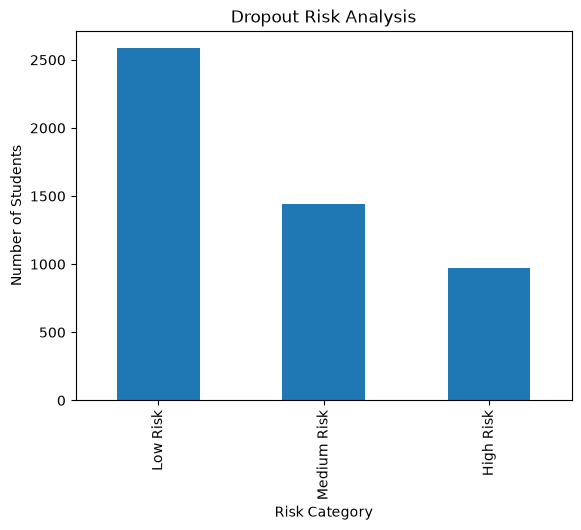

In [ ]:
import matplotlib.pyplot as plt

risk_df['Dropout_Risk'].value_counts().plot(
    kind='bar'
)

plt.title(
    "Dropout Risk Analysis"
)

plt.xlabel(
    "Risk Category"
)

plt.ylabel(
    "Number of Students"
)

plt.show()

In [ ]:
# ==========================================
# PERSONALIZED RECOMMENDATIONS
# ==========================================

def recommendation(row):

    recommendations = []

    if row['Attendance (%)'] < 75:
        recommendations.append(
            "Improve attendance"
        )

    if row['Study_Hours_per_Week'] < 12:
        recommendations.append(
            "Increase study hours"
        )

    if row['Sleep_Hours_per_Night'] < 6:
        recommendations.append(
            "Maintain proper sleep schedule"
        )

    if row['Stress_Level (1-10)'] > 7:
        recommendations.append(
            "Reduce stress through planning"
        )

    if len(recommendations) == 0:

        return (
            "Excellent Performance"
        )

    return (
        ", ".join(recommendations)
    )

risk_df[
    'Recommendation'
] = risk_df.apply(
    recommendation,
    axis=1
)

risk_df[
    [
        'Attendance (%)',
        'Study_Hours_per_Week',
        'Stress_Level (1-10)',
        'Recommendation'
    ]
].head(5)

,Attendance (%),Study_Hours_per_Week,Stress_Level (1-10),Recommendation
0,97.36,10.3,1,"Increase study hours, Maintain proper sleep sc..."
1,97.71,27.1,4,Maintain proper sleep schedule
2,99.52,12.4,9,Reduce stress through planning
3,90.38,25.5,8,"Maintain proper sleep schedule, Reduce stress ..."
4,59.41,13.3,6,"Improve attendance, Maintain proper sleep sche..."


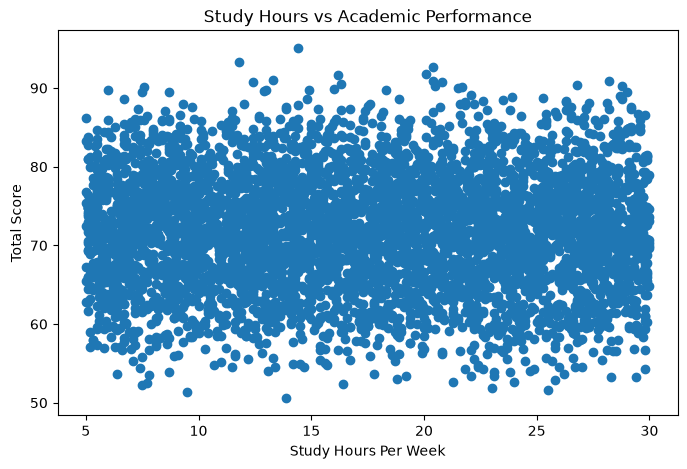

In [ ]:
# ==========================================
# TIME MANAGEMENT ANALYSIS
# ==========================================

import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,5)
)

plt.scatter(
    clean_df['Study_Hours_per_Week'],
    clean_df['Total_Score']
)

plt.xlabel(
    "Study Hours Per Week"
)

plt.ylabel(
    "Total Score"
)

plt.title(
    "Study Hours vs Academic Performance"
)

plt.show()

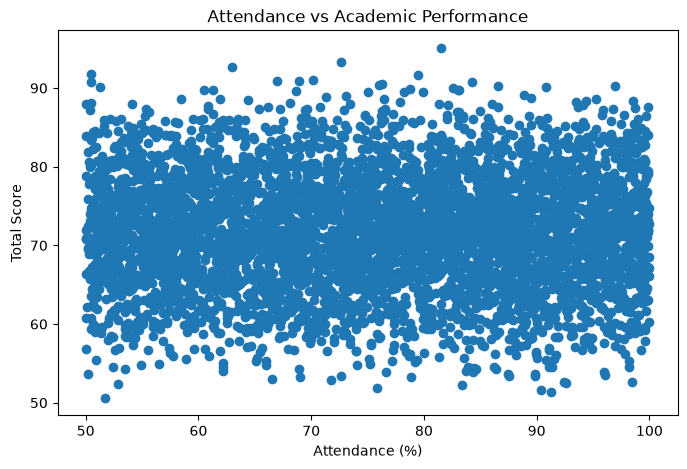

In [ ]:
# ==========================================
# ATTENDANCE IMPACT ANALYSIS
# ==========================================

plt.figure(
    figsize=(8,5)
)

plt.scatter(
    clean_df['Attendance (%)'],
    clean_df['Total_Score']
)

plt.xlabel(
    "Attendance (%)"
)

plt.ylabel(
    "Total Score"
)

plt.title(
    "Attendance vs Academic Performance"
)

plt.show()

In [ ]:
feature_importance.head(10)

,Feature,Importance
5,Final_Score,0.238943
9,Projects_Score,0.214584
4,Midterm_Score,0.129374
6,Assignments_Avg,0.097821
8,Participation_Score,0.070506
7,Quizzes_Avg,0.066749
10,Study_Hours_per_Week,0.029962
3,Attendance (%),0.029296
16,Sleep_Hours_per_Night,0.027034
1,Age,0.018641
